In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

print("1. Veri yükleniyor ve dönüştürülüyor, lütfen bekleyin...")

df = pd.read_csv('NIPS_1987-2015.csv')

# 'Unnamed: 0' sütununu satır isimleri (index) olarak ayarlıyoruz
df.set_index('Unnamed: 0', inplace=True)

# Matrisin Transpozunu alıyoruz. (Satırlar ve sütunlar yer değiştiriyor)
# Artık satırlar makaleler ('1987_1' vb.), sütunlar ise kelimeler oldu.
df_T = df.T

print("2. Hedef değişken (Dönem) oluşturuluyor...")

# Satır isimlerinden (örneğin '1987_1') yılı çekip yeni bir 'Yil' sütunu oluşturuyoruz
df_T['Yil'] = df_T.index.map(lambda x: int(str(x).split('_')[0]))

# 1987-2000 arası: 0 (Klasik Dönem), 2001-2015 arası: 1 (Modern Dönem)
df_T['Donem'] = df_T['Yil'].apply(lambda x: 0 if x <= 2000 else 1)

# Girdi (X) ve Hedef (y) ayrımı
X = df_T.drop(columns=['Yil', 'Donem'])
y = df_T['Donem']

X = X.fillna(0)
X.columns = X.columns.astype(str)

print(f"Toplam Makale Sayısı: {X.shape[0]}")
print(f"Kullanılan Kelime Sayısı: {X.shape[1]}")

# Veriyi Eğitim (%80) ve Test (%20) olarak bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model tanımlama
modeller = {
    "Lojistik Regresyon": LogisticRegression(max_iter=1000),
    "Basit Bayes": MultinomialNB(),
    "Karar Ağacı": DecisionTreeClassifier(random_state=42),
    "Rastgele Orman": RandomForestClassifier(random_state=42),
    "K-En Yakın Komşu": KNeighborsClassifier(n_neighbors=5),
    "YSA": MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42),
    "SVM (Destek Vektör Makinesi)": SVC(kernel='linear', random_state=42)
}

print("\n--- ALGORİTMA DOĞRULUK SONUÇLARI ---")
print("Modeller eğitiliyor, bu işlem veri büyüklüğünden dolayı 1-2 dakika sürebilir...\n")

for isim, model in modeller.items():
    # Modeli eğit
    model.fit(X_train, y_train)
    # Tahmin yap
    tahminler = model.predict(X_test)
    # Doğruluk (Accuracy) skorunu hesapla
    dogruluk = accuracy_score(y_test, tahminler)

    print(f"{isim}: {dogruluk:.4f}")

1. Veri yükleniyor ve dönüştürülüyor, lütfen bekleyin...
2. Hedef değişken (Dönem) oluşturuluyor...
Toplam Makale Sayısı: 5811
Kullanılan Kelime Sayısı: 11463

--- ALGORİTMA DOĞRULUK SONUÇLARI ---
Modeller eğitiliyor, bu işlem veri büyüklüğünden dolayı 1-2 dakika sürebilir...

Lojistik Regresyon: 0.9037
Basit Bayes: 0.8641
Karar Ağacı: 0.8323
Rastgele Orman: 0.9175
K-En Yakın Komşu: 0.5985
YSA: 0.9475
SVM (Destek Vektör Makinesi): 0.8917


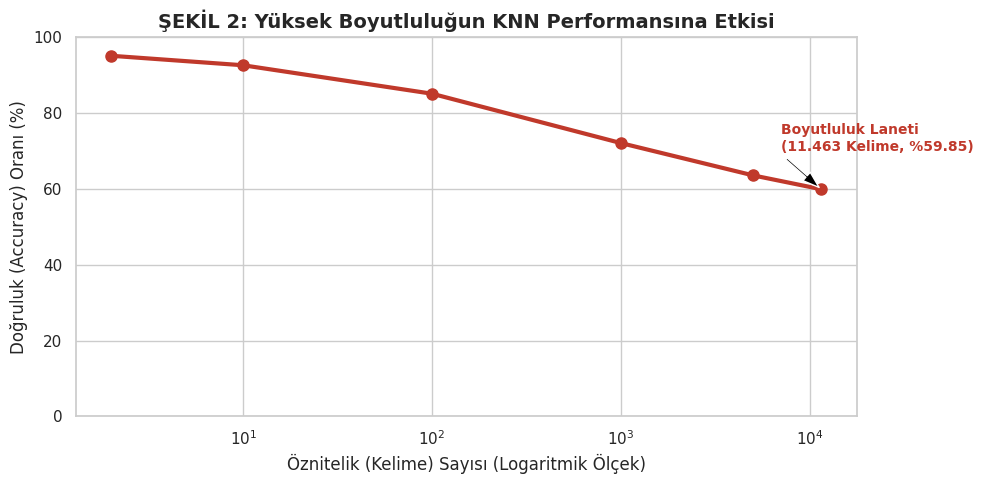

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# Temsili veri: Öznitelik sayısı artarken KNN doğruluk oranının düşüşü
oznitelik_sayisi = [2, 10, 100, 1000, 5000, 11463]
knn_dogruluk = [95.0, 92.5, 85.0, 72.0, 63.5, 59.85]

# Çizgi grafiği çizimi
plt.plot(oznitelik_sayisi, knn_dogruluk, marker='o', linewidth=3, color='#c0392b', markersize=8)

# Boyutluluk Laneti noktasını işaretleme
plt.annotate('Boyutluluk Laneti\n(11.463 Kelime, %59.85)',
             xy=(11463, 59.85), xytext=(7000, 70),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=10, fontweight='bold', color='#c0392b')

plt.title('ŞEKİL 2: Yüksek Boyutluluğun KNN Performansına Etkisi', fontsize=14, fontweight='bold')
plt.xlabel('Öznitelik (Kelime) Sayısı (Logaritmik Ölçek)', fontsize=12)
plt.ylabel('Doğruluk (Accuracy) Oranı (%)', fontsize=12)

# X eksenini logaritmik yaparak değişimi daha net gösterme
plt.xscale('log')
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

/tmp/ipykernel_6254/1265224748.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafik = sns.barplot(x=modeller, y=dogruluk, palette=renkler)


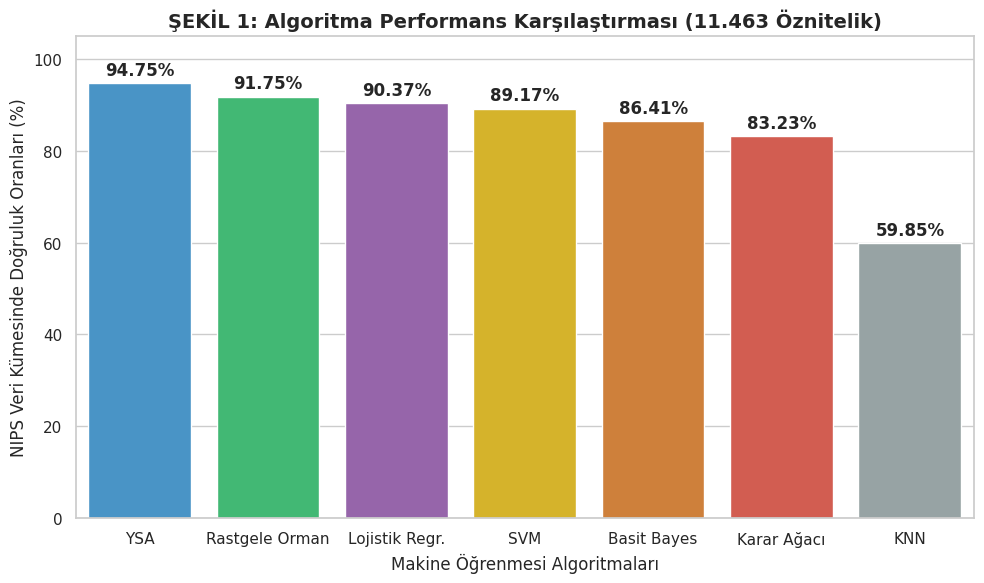

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

modeller = ['YSA', 'Rastgele Orman', 'Lojistik Regr.', 'SVM', 'Basit Bayes', 'Karar Ağacı', 'KNN']
dogruluk = [94.75, 91.75, 90.37, 89.17, 86.41, 83.23, 59.85]

# Renk paleti oluşturma
renkler = ['#3498db', '#2ecc71', '#9b59b6', '#f1c40f', '#e67e22', '#e74c3c', '#95a5a6']

grafik = sns.barplot(x=modeller, y=dogruluk, palette=renkler)

plt.title('ŞEKİL 1: Algoritma Performans Karşılaştırması (11.463 Öznitelik)', fontsize=14, fontweight='bold')
plt.xlabel('Makine Öğrenmesi Algoritmaları', fontsize=12)
plt.ylabel('NIPS Veri Kümesinde Doğruluk Oranları (%)', fontsize=12)
plt.ylim(0, 105)

# Barların üzerine değerleri yazdırma
for i in grafik.containers:
    grafik.bar_label(i, fmt='%.2f%%', padding=3, fontweight='bold')

plt.tight_layout()
plt.show()